# MNIST Digit Classification with PyTorch

This notebook trains and compares two neural networks for recognizing handwritten digits (0 to 9) from the MNIST dataset.


## 1. Imports and Device Setup

We import the core PyTorch modules:
- `torch` provides the main library and tensor operations
- `torch.nn` provides neural network layers (Linear, Conv2d, etc.)
- `torch.optim` provides optimizers like SGD and Adam
- `torch.nn.functional` provides stateless functions like `relu` and `softmax`
- `DataLoader` handles batching and shuffling
- `torchvision` provides MNIST, image transforms, and pretrained models

We also add `matplotlib` for plotting and `numpy` for the analysis section later.

The `device` variable picks the GPU (`cuda`) if available, otherwise falls back to CPU. Moving tensors and models to the GPU is what makes training fast.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Using device: {device}')

PyTorch version: 2.10.0+cu128
Using device: cuda


## 2. Loading and Preparing MNIST

MNIST is a classic dataset of 70,000 grayscale 28x28 images of handwritten digits (60k training plus 10k test).

**Transform pipeline:**
1. `ToTensor()` converts PIL images (0 to 255) into PyTorch tensors of shape `[1, 28, 28]` with values scaled to `[0, 1]`.
2. `Normalize(mean, std)` standardizes pixels using MNIST's known statistics (mean 0.1307, std 0.3081):

$$x_{\text{norm}} = \frac{x - 0.1307}{0.3081}$$

Centering inputs around zero helps optimization converge faster.

**DataLoaders** wrap the datasets to provide:
- Batching: feeds the model 64 images at a time during training
- Shuffling: training data is shuffled each epoch (test data is not)
- Larger test batches (1000) because no gradients are computed during evaluation

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 557kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]

Training samples: 60000
Test samples: 10000


## 3. Previewing Samples

Quick sanity check: grab one batch of images and plot the first six along with their ground-truth labels. If the labels match the digits, we know the data pipeline is working correctly.

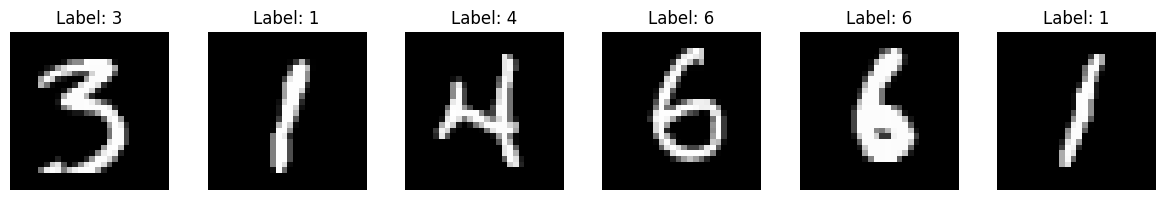

In [4]:
examples = iter(train_loader)
images, labels = next(examples)

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    axes[i].imshow(images[i][0], cmap='gray')
    axes[i].set_title(f'Label: {labels[i].item()}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 4. Defining the MLP Neural Network

A simple Multi-Layer Perceptron (MLP) with three fully-connected layers:

| Layer  | Input | Output | Notes |
|--------|------:|-------:|-------|
| `fc1`  |   784 |    128 | Takes flattened 28x28 image, outputs 128 hidden units |
| `fc2`  |   128 |     64 | Compresses further into 64 features |
| `fc3`  |    64 |     10 | One score (logit) per digit class 0 to 9 |

**Forward pass:**
1. `x.view(-1, 28*28)` flattens each image from `[1, 28, 28]` into a 784-vector.
2. Apply `fc1` then ReLU activation: $f(x) = \max(0, x)$ to introduce non-linearity.
3. Apply `fc2` then ReLU again.
4. Apply `fc3` to output raw logits (no softmax). `CrossEntropyLoss` applies softmax internally during training.

`.to(device)` moves all model parameters to the GPU.

In [5]:
class DigitNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

mlp_model = DigitNN().to(device)
print(mlp_model)

mlp_params = sum(p.numel() for p in mlp_model.parameters())
print(f'\nTotal parameters: {mlp_params:,}')

DigitNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

Total parameters: 109,386


## 5. Training the MLP

**Loss function:** `CrossEntropyLoss`, the standard for multi-class classification. Combines softmax with negative log-likelihood:

$$\mathcal{L} = -\log\!\left(\frac{e^{z_y}}{\sum_j e^{z_j}}\right)$$

where $z_y$ is the logit for the correct class.

**Optimizer:** `Adam` with learning rate `0.001`, an adaptive optimizer that works well by default.

**Each training step:**
1. Move batch to GPU
2. Forward pass to compute predictions (`outputs`)
3. Compute loss vs. true labels
4. `zero_grad()` to clear old gradients (PyTorch accumulates by default)
5. `backward()` to backpropagate and compute gradients
6. `step()` to update weights using the gradients

We also track running loss and accuracy across each epoch for monitoring, and the total training time.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

num_epochs = 5
mlp_start = time.time()

for epoch in range(num_epochs):
    mlp_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = mlp_model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / len(train_loader)
    accuracy = 100.0 * correct / total
    print(f'Epoch [{epoch+1}/{num_epochs}]  Loss: {avg_loss:.4f}  Accuracy: {accuracy:.2f}%')

mlp_train_time = time.time() - mlp_start
print(f'\nMLP training complete in {mlp_train_time:.1f} seconds.')

Epoch [1/5]  Loss: 0.2793  Accuracy: 91.75%
Epoch [2/5]  Loss: 0.1153  Accuracy: 96.44%
Epoch [3/5]  Loss: 0.0811  Accuracy: 97.46%
Epoch [4/5]  Loss: 0.0622  Accuracy: 97.98%
Epoch [5/5]  Loss: 0.0512  Accuracy: 98.35%

MLP training complete in 73.2 seconds.


## 6. Evaluating the MLP on the Test Set

Two important differences from training:

- `torch.no_grad()` disables gradient tracking, saving memory and time since we are not updating weights.

We compute average loss and accuracy across all 10,000 test images. The gap between train and test accuracy tells us about overfitting.

In [7]:
correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = mlp_model(images)
        test_loss += criterion(outputs, labels).item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

mlp_test_loss = test_loss / len(test_loader)
mlp_test_acc = 100.0 * correct / total
print(f'MLP Test Loss: {mlp_test_loss:.4f}')
print(f'MLP Test Accuracy: {mlp_test_acc:.2f}%  ({correct}/{total})')

MLP Test Loss: 0.0842
MLP Test Accuracy: 97.32%  (9732/10000)


## 7. Visualizing MLP Predictions

Display 12 test images in a 2x6 grid with predicted and true labels.

- Green title means the prediction matches the true label.
- Red title means it was misclassified.


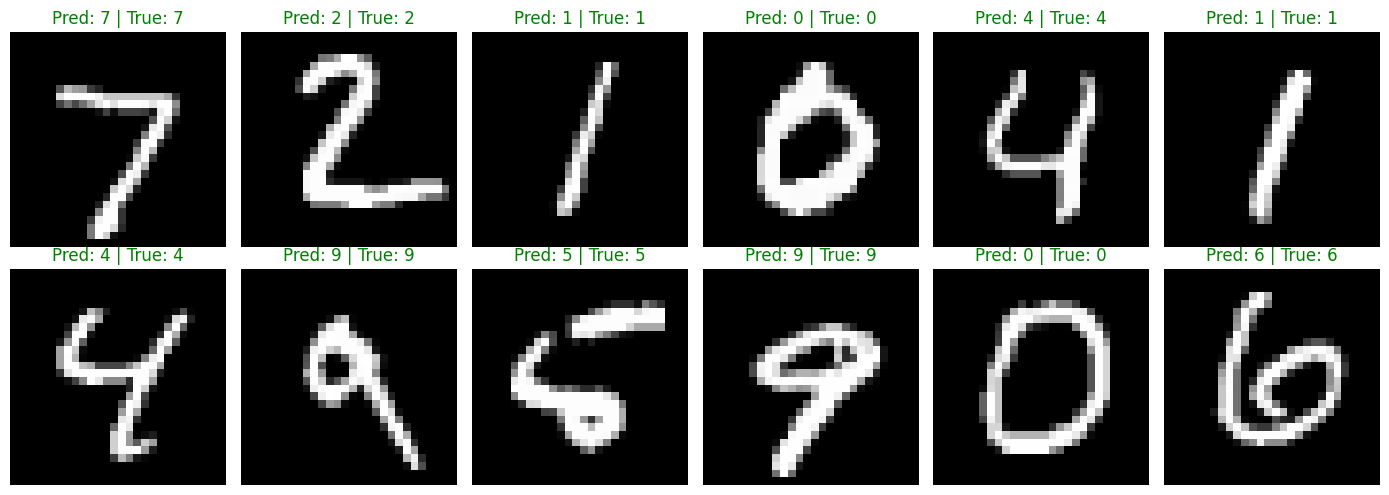

In [8]:
examples = iter(test_loader)
images, labels = next(examples)
images_dev = images.to(device)

with torch.no_grad():
    outputs = mlp_model(images_dev)
    _, preds = outputs.max(1)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i][0], cmap='gray')
    color = 'green' if preds[i].item() == labels[i].item() else 'red'
    ax.set_title(f'Pred: {preds[i].item()} | True: {labels[i].item()}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 8. In-Depth Accuracy Analysis


We run the model once on the entire test set and collect all predictions, true labels, and softmax probabilities for the analysis.

In [9]:
def collect_predictions(model, loader, transform_input=None):
    """Run a model over a loader and return (preds, labels, probs, images)."""
    model.eval()
    all_preds, all_labels, all_probs, all_images = [], [], [], []

    with torch.no_grad():
        for images, labels in loader:
            inp = images.to(device)
            if transform_input is not None:
                inp = transform_input(inp)
            outputs = model(inp)
            probs = F.softmax(outputs, dim=1)
            _, preds = outputs.max(1)

            all_preds.append(preds.cpu())
            all_labels.append(labels)
            all_probs.append(probs.cpu())
            all_images.append(images)

    return (
        torch.cat(all_preds).numpy(),
        torch.cat(all_labels).numpy(),
        torch.cat(all_probs).numpy(),
        torch.cat(all_images),
    )

mlp_preds, mlp_labels, mlp_probs, mlp_images = collect_predictions(mlp_model, test_loader)
print(f'Collected predictions for {len(mlp_preds)} test samples')
print(f'Overall MLP accuracy: {100.0 * (mlp_preds == mlp_labels).mean():.2f}%')

Collected predictions for 10000 test samples
Overall MLP accuracy: 97.32%


### 8.1 Per-Class Accuracy

For each digit 0 to 9, compute the fraction of test images of that digit that the model classified correctly. This reveals whether some digits are systematically harder than others.

 Digit |  Correct |  Total |  Accuracy
----------------------------------------
     0 |      964 |    980 |    98.37%
     1 |     1126 |   1135 |    99.21%
     2 |      983 |   1032 |    95.25%
     3 |      999 |   1010 |    98.91%
     4 |      949 |    982 |    96.64%
     5 |      861 |    892 |    96.52%
     6 |      936 |    958 |    97.70%
     7 |      994 |   1028 |    96.69%
     8 |      933 |    974 |    95.79%
     9 |      987 |   1009 |    97.82%


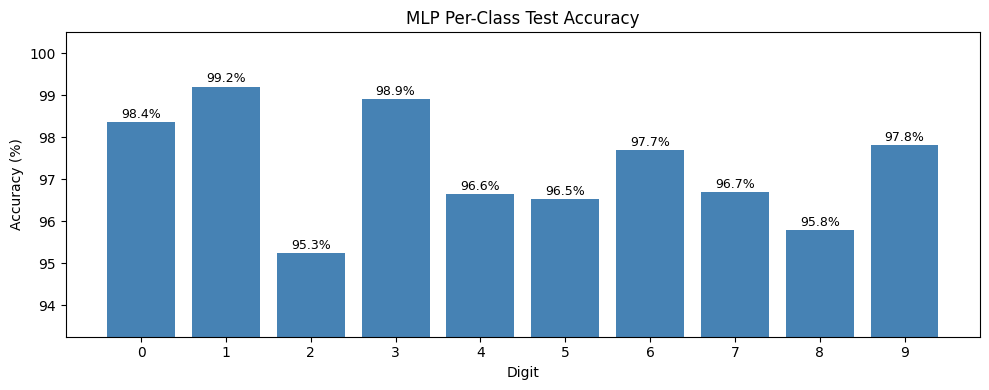

In [10]:
def per_class_accuracy(preds, labels, title='Per-Class Test Accuracy'):
    print(f"{'Digit':>6} | {'Correct':>8} | {'Total':>6} | {'Accuracy':>9}")
    print('-' * 40)
    accs = []
    for digit in range(10):
        mask = labels == digit
        total_d = mask.sum()
        correct_d = (preds[mask] == digit).sum()
        acc = 100.0 * correct_d / total_d
        accs.append(acc)
        print(f'{digit:>6} | {correct_d:>8} | {total_d:>6} | {acc:>8.2f}%')

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(range(10), accs, color='steelblue')
    ax.set_xticks(range(10))
    ax.set_xlabel('Digit')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(title)
    ax.set_ylim(min(accs) - 2, 100.5)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f'{acc:.1f}%', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    return accs

mlp_class_acc = per_class_accuracy(mlp_preds, mlp_labels, 'MLP Per-Class Test Accuracy')

### 8.2 Confusion Matrix

Element $(i, j)$ of the matrix is the count of test images whose true label is $i$ but were predicted as $j$. The diagonal contains correct predictions; off-diagonal entries reveal which digits get confused with which.

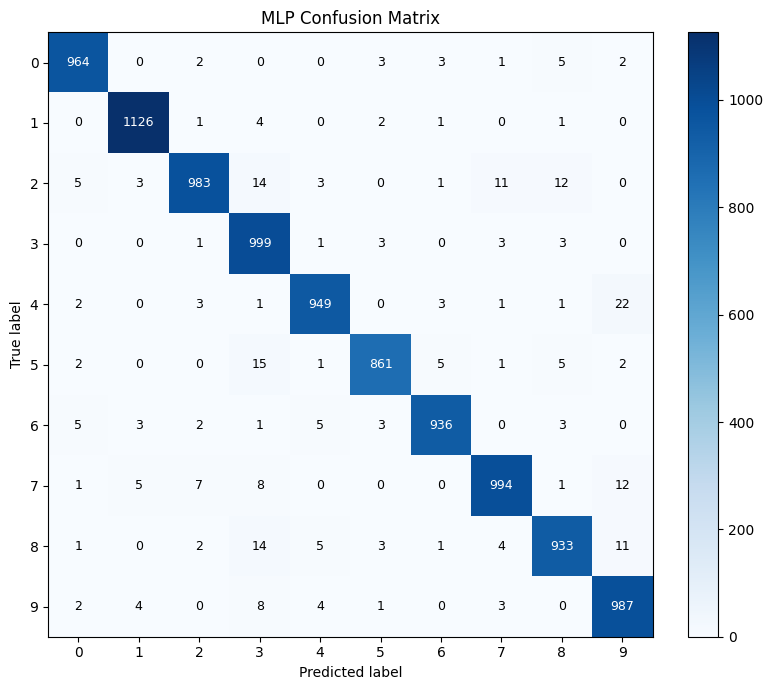


Top 5 most common confusions:
  True 4 predicted as 9: 22 times
  True 5 predicted as 3: 15 times
  True 8 predicted as 3: 14 times
  True 2 predicted as 3: 14 times
  True 7 predicted as 9: 12 times


In [11]:
def confusion_matrix(preds, labels, title='Confusion Matrix'):
    cm = np.zeros((10, 10), dtype=int)
    for t, p in zip(labels, preds):
        cm[t, p] += 1

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_title(title)

    threshold = cm.max() / 2
    for i in range(10):
        for j in range(10):
            color = 'white' if cm[i, j] > threshold else 'black'
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color=color, fontsize=9)

    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()

    confusions = []
    for i in range(10):
        for j in range(10):
            if i != j and cm[i, j] > 0:
                confusions.append((cm[i, j], i, j))
    confusions.sort(reverse=True)
    print('\nTop 5 most common confusions:')
    for count, true_d, pred_d in confusions[:5]:
        print(f'  True {true_d} predicted as {pred_d}: {count} times')
    return cm

mlp_cm = confusion_matrix(mlp_preds, mlp_labels, 'MLP Confusion Matrix')

## 9. Building a CNN with a Pretrained Backbone (ResNet18)

Now we build a convolutional neural network using **transfer learning**. Specifically, we take a `ResNet18` model that was pretrained on ImageNet (a large dataset of natural color images) and fine-tune it for MNIST.

**Why use a pretrained model?**
Early CNN layers learn generic image features (edges, textures, simple shapes) that are useful for almost any image task. Reusing those weights gives us a head start instead of learning from scratch.

**Adapting ResNet18 to MNIST requires two changes:**
1. ResNet expects 3-channel (RGB) input but MNIST is grayscale (1 channel). We replace `conv1` with a new 1-channel convolution (or alternatively repeat the channel three times). Here we replace `conv1` cleanly so the model is small.
2. ResNet's final fully-connected layer outputs 1000 classes (ImageNet). We replace it with a new `Linear` layer that outputs 10 classes.

**Resizing:** ResNet was designed for 224x224 images. MNIST is 28x28. We resize MNIST images up to 64x64 in the input pipeline, which is enough for ResNet's stride structure while keeping training fast.

**Fine-tuning strategy:** We keep all ImageNet weights as the starting point and update them all during training.

In [12]:
cnn_transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset_cnn = datasets.MNIST(root='./data', train=True, download=True, transform=cnn_transform)
test_dataset_cnn  = datasets.MNIST(root='./data', train=False, download=True, transform=cnn_transform)

train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader_cnn  = DataLoader(test_dataset_cnn,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

print(f'CNN input image shape: {train_dataset_cnn[0][0].shape}')

CNN input image shape: torch.Size([1, 64, 64])


In [13]:
def build_resnet18_for_mnist(pretrained=True):
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.resnet18(weights=weights)

    # Replace the first conv layer: 1 input channel instead of 3.
    # We initialize the new conv from the pretrained 3-channel conv by averaging across channels,
    # which preserves most of the learned filter structure for grayscale input.
    old_conv = model.conv1
    new_conv = nn.Conv2d(1, old_conv.out_channels,
                         kernel_size=old_conv.kernel_size,
                         stride=old_conv.stride,
                         padding=old_conv.padding,
                         bias=old_conv.bias is not None)
    if pretrained:
        with torch.no_grad():
            new_conv.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)
    model.conv1 = new_conv

    # Replace the final classifier: 1000 -> 10
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 10)
    return model

cnn_model = build_resnet18_for_mnist(pretrained=True).to(device)
cnn_params = sum(p.numel() for p in cnn_model.parameters())
print(f'ResNet18 total parameters: {cnn_params:,}')
print('\nFirst conv layer:', cnn_model.conv1)
print('Final layer:', cnn_model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


ResNet18 total parameters: 11,175,370

First conv layer: Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Final layer: Linear(in_features=512, out_features=10, bias=True)


### 9.1 Training the CNN

We use the same `CrossEntropyLoss` and `Adam` optimizer, but with a slightly lower learning rate (`3e-4`) since the model already has good pretrained weights and we do not want to destroy them with overly large updates.

We train for 3 epochs only because pretrained models usually converge faster than randomly initialized ones, and ResNet18 is much larger than our MLP.

In [14]:
cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=3e-4)

cnn_epochs = 3
cnn_start = time.time()

for epoch in range(cnn_epochs):
    cnn_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_cnn:
        images, labels = images.to(device), labels.to(device)

        outputs = cnn_model(images)
        loss = cnn_criterion(outputs, labels)

        cnn_optimizer.zero_grad()
        loss.backward()
        cnn_optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / len(train_loader_cnn)
    accuracy = 100.0 * correct / total
    print(f'Epoch [{epoch+1}/{cnn_epochs}]  Loss: {avg_loss:.4f}  Accuracy: {accuracy:.2f}%')

cnn_train_time = time.time() - cnn_start
print(f'\nCNN training complete in {cnn_train_time:.1f} seconds.')

Epoch [1/3]  Loss: 0.0714  Accuracy: 97.90%
Epoch [2/3]  Loss: 0.0247  Accuracy: 99.27%
Epoch [3/3]  Loss: 0.0194  Accuracy: 99.45%

CNN training complete in 71.8 seconds.


### 9.2 Evaluating the CNN on the Test Set

Same evaluation procedure as the MLP, but using the CNN-specific test loader (with resized 64x64 images).

In [15]:
cnn_model.eval()
correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader_cnn:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        test_loss += cnn_criterion(outputs, labels).item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

cnn_test_loss = test_loss / len(test_loader_cnn)
cnn_test_acc = 100.0 * correct / total
print(f'CNN Test Loss: {cnn_test_loss:.4f}')
print(f'CNN Test Accuracy: {cnn_test_acc:.2f}%  ({correct}/{total})')

CNN Test Loss: 0.0195
CNN Test Accuracy: 99.41%  (9941/10000)


### 9.3 Detailed CNN Analysis

Run the same per-class accuracy, confusion matrix, confidence histogram, and confident-mistake gallery on the CNN. This lets us compare strengths and weaknesses between the two models directly.

Overall CNN accuracy: 99.41%
 Digit |  Correct |  Total |  Accuracy
----------------------------------------
     0 |      975 |    980 |    99.49%
     1 |     1128 |   1135 |    99.38%
     2 |     1028 |   1032 |    99.61%
     3 |     1006 |   1010 |    99.60%
     4 |      977 |    982 |    99.49%
     5 |      885 |    892 |    99.22%
     6 |      947 |    958 |    98.85%
     7 |     1019 |   1028 |    99.12%
     8 |      973 |    974 |    99.90%
     9 |     1003 |   1009 |    99.41%


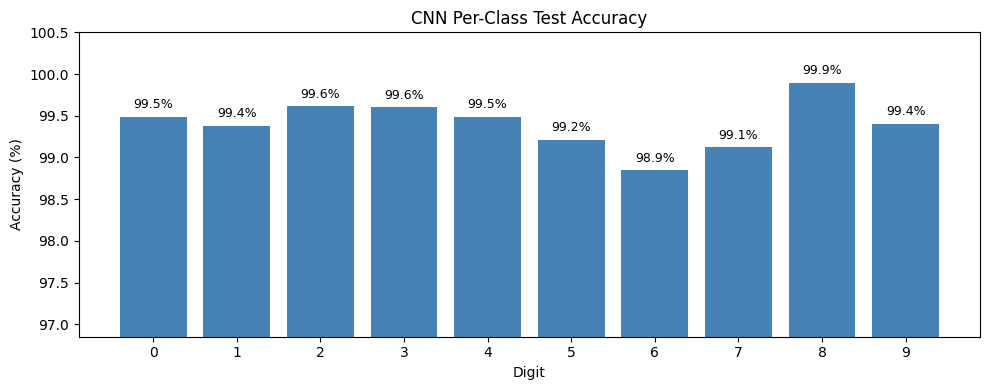

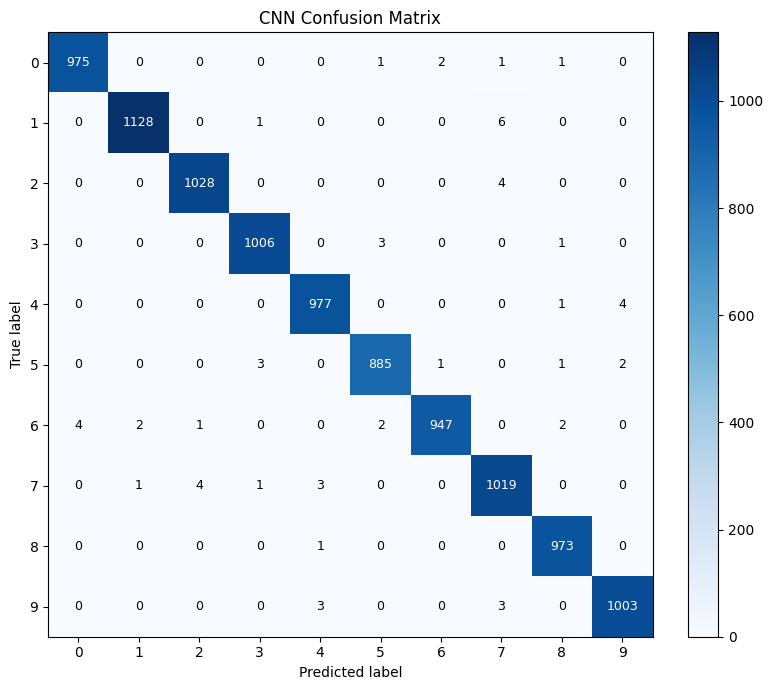


Top 5 most common confusions:
  True 1 predicted as 7: 6 times
  True 7 predicted as 2: 4 times
  True 6 predicted as 0: 4 times
  True 4 predicted as 9: 4 times
  True 2 predicted as 7: 4 times


In [16]:
cnn_preds, cnn_labels, cnn_probs, cnn_images = collect_predictions(cnn_model, test_loader_cnn)
print(f'Overall CNN accuracy: {100.0 * (cnn_preds == cnn_labels).mean():.2f}%')

cnn_class_acc = per_class_accuracy(cnn_preds, cnn_labels, 'CNN Per-Class Test Accuracy')
cnn_cm = confusion_matrix(cnn_preds, cnn_labels, 'CNN Confusion Matrix')


## 10. Side-by-Side Comparison

Finally, compile the headline numbers and per-class accuracies into a single comparison view. We can see at a glance:
- Which model is more accurate overall
- Where the accuracy gains come from (which digits improved most)
- The tradeoff in parameter count and training time

Metric                                  MLP  CNN (ResNet18)
Parameters                          109,386      11,175,370
Training time (s)                      73.2            71.8
Test loss                            0.0842          0.0195
Test accuracy (%)                     97.32           99.41
Errors out of 10,000                    268              59


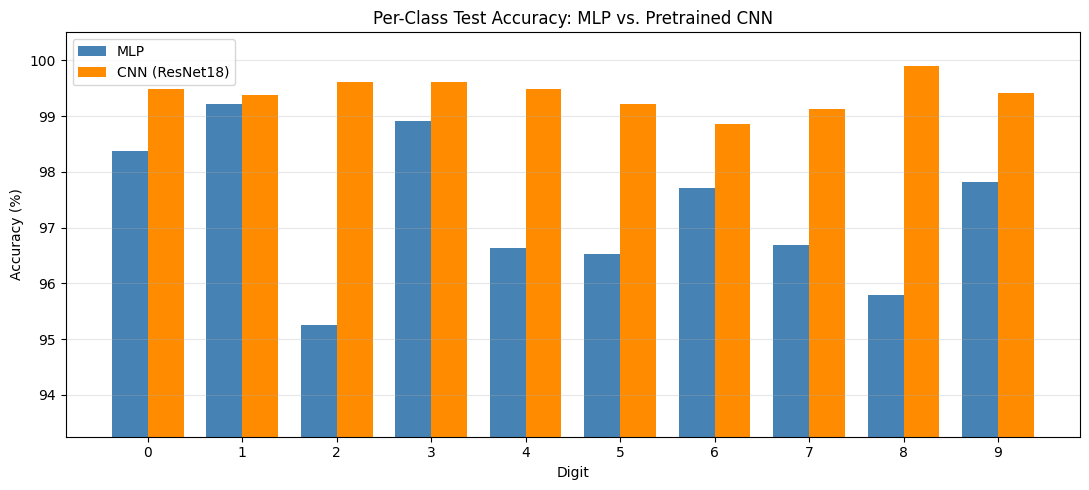

In [17]:
print('=' * 60)
print(f"{'Metric':<30} {'MLP':>12} {'CNN (ResNet18)':>15}")
print('=' * 60)
print(f"{'Parameters':<30} {mlp_params:>12,} {cnn_params:>15,}")
print(f"{'Training time (s)':<30} {mlp_train_time:>12.1f} {cnn_train_time:>15.1f}")
print(f"{'Test loss':<30} {mlp_test_loss:>12.4f} {cnn_test_loss:>15.4f}")
print(f"{'Test accuracy (%)':<30} {mlp_test_acc:>12.2f} {cnn_test_acc:>15.2f}")
print(f"{'Errors out of 10,000':<30} {int(round((100-mlp_test_acc)*100)):>12} {int(round((100-cnn_test_acc)*100)):>15}")
print('=' * 60)

# Per-class comparison plot
x = np.arange(10)
width = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, mlp_class_acc, width, label='MLP', color='steelblue')
ax.bar(x + width/2, cnn_class_acc, width, label='CNN (ResNet18)', color='darkorange')
ax.set_xticks(x)
ax.set_xlabel('Digit')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Test Accuracy: MLP vs. Pretrained CNN')
ax.set_ylim(min(min(mlp_class_acc), min(cnn_class_acc)) - 2, 100.5)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()